In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [28]:
df = pd.read_csv("learningexperience.csv")
df = df.drop(columns=["id","tasks", "total"])

In [29]:
df.head()

,date,week,task_cat,start,end,personal_enjoyment,stress_level,strasfactory_level
0,06-29-2025,1,Admin & Onboarding,20:30,23:00,5,6,6
1,07-02-2025,1,Admin & Onboarding,20:30,21:00,5,3,5
2,07-03-2025,1,Research & Academic Operations,20:00,22:00,6,4,6
3,07-09-2025,2,Skill Acquisition & Courses,13:00,17:00,6,4,6
4,07-09-2025,2,Academic Writing & Literature,18:00,23:00,7,4,7


In [30]:
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%Y', errors='coerce')

# 2. Convert to datetime objects first to allow subtraction
start_dt = pd.to_datetime(df['start'], format='%H:%M')
end_dt = pd.to_datetime(df['end'], format='%H:%M')

# 3. Calculate duration (Timedelta)
df['duration'] = end_dt - start_dt

# 4. NOW convert the original columns to time objects if you need them that way
df['start'] = start_dt.dt.time
df['end'] = end_dt.dt.time

In [31]:
df.head()

,date,week,task_cat,start,end,personal_enjoyment,stress_level,strasfactory_level,duration
0,2025-06-29,1,Admin & Onboarding,20:30:00,23:00:00,5,6,6,0 days 02:30:00
1,2025-07-02,1,Admin & Onboarding,20:30:00,21:00:00,5,3,5,0 days 00:30:00
2,2025-07-03,1,Research & Academic Operations,20:00:00,22:00:00,6,4,6,0 days 02:00:00
3,2025-07-09,2,Skill Acquisition & Courses,13:00:00,17:00:00,6,4,6,0 days 04:00:00
4,2025-07-09,2,Academic Writing & Literature,18:00:00,23:00:00,7,4,7,0 days 05:00:00


In [32]:
df['duration'] = (pd.to_timedelta(df['duration']).dt.total_seconds() / 3600).abs()

In [33]:
df.head()

,date,week,task_cat,start,end,personal_enjoyment,stress_level,strasfactory_level,duration
0,2025-06-29,1,Admin & Onboarding,20:30:00,23:00:00,5,6,6,2.5
1,2025-07-02,1,Admin & Onboarding,20:30:00,21:00:00,5,3,5,0.5
2,2025-07-03,1,Research & Academic Operations,20:00:00,22:00:00,6,4,6,2.0
3,2025-07-09,2,Skill Acquisition & Courses,13:00:00,17:00:00,6,4,6,4.0
4,2025-07-09,2,Academic Writing & Literature,18:00:00,23:00:00,7,4,7,5.0


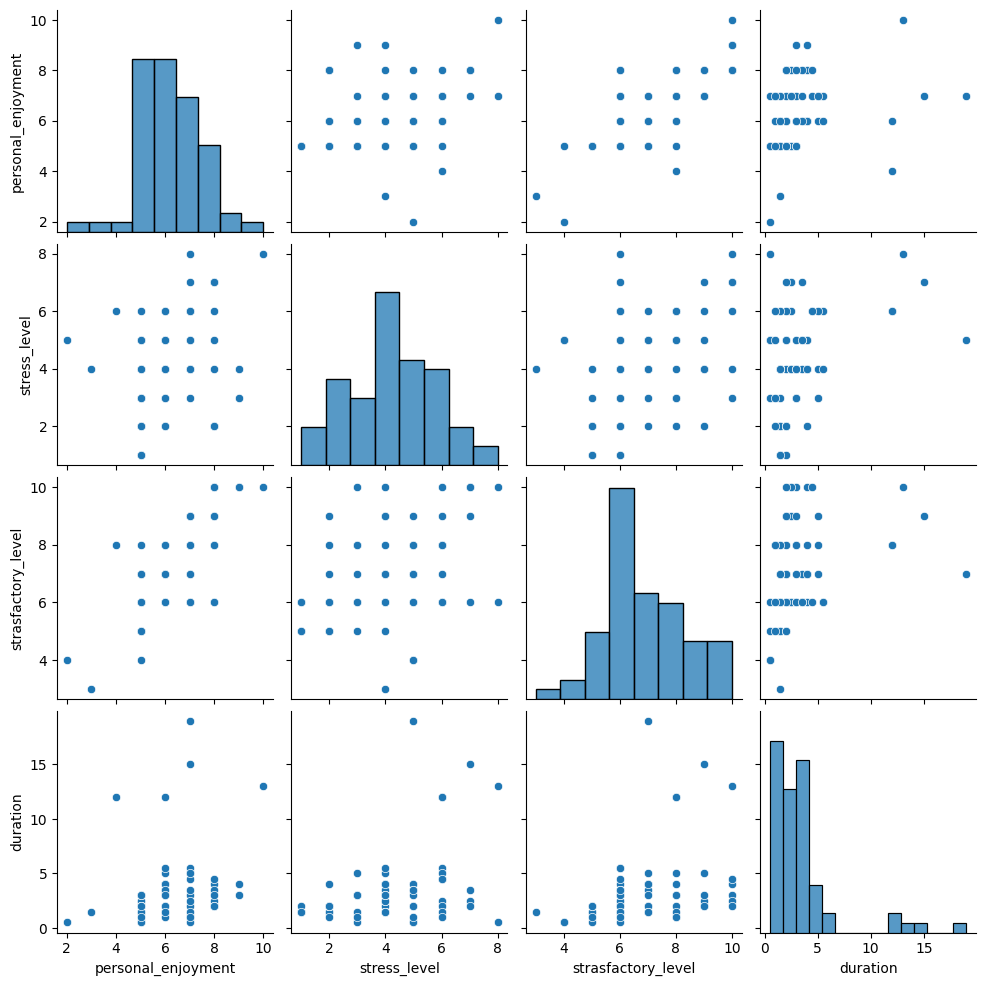

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your 4 specific columns
target_cols = ['personal_enjoyment', 'stress_level', 'strasfactory_level', 'duration']

# Generate the 4x4 grid automatically
sns.pairplot(df[target_cols])
plt.show()


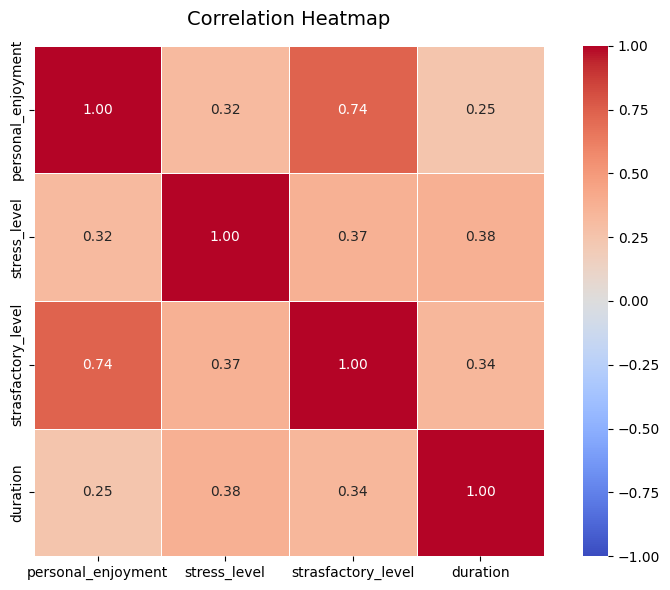

In [35]:
target_cols = ['personal_enjoyment', 'stress_level', 'strasfactory_level', 'duration']

# 1. Calculate the correlation matrix (defaults to Pearson)
corr_matrix = df[target_cols].corr()

# 2. Set up the matplotlib canvas
plt.figure(figsize=(8, 6))

# 3. Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation numbers inside the squares
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="coolwarm",     # Red for positive correlation, blue for negative
    vmin=-1, vmax=1,     # Fix the scale boundaries between -1 and 1
    linewidths=0.5,      # Add subtle lines separating the cells
    square=True          # Force cells to be perfectly square
)

plt.title('Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


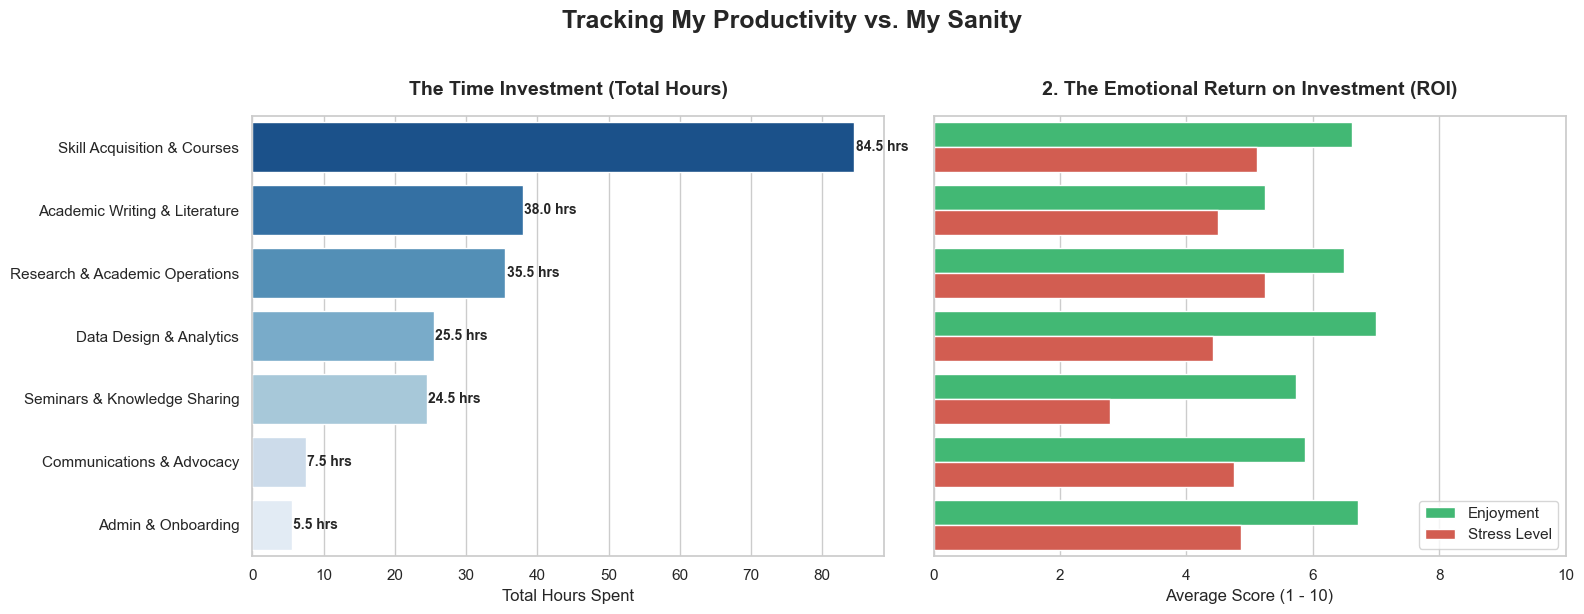

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_spent = df.groupby('task_cat')['duration'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    x='duration', 
    y='task_cat', 
    data=time_spent, 
    ax=ax1, 
    palette="Blues_r",
    hue='task_cat',
    legend=False
)
ax1.set_title("The Time Investment (Total Hours)", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Total Hours Spent", fontsize=12)
ax1.set_ylabel("", fontsize=12)

for p in ax1.patches:
    ax1.annotate(f"{p.get_width():.1f} hrs", 
                 (p.get_width() + 0.2, p.get_y() + p.get_height()/2), 
                 va='center', fontsize=10, fontweight='bold')

emotional_roi = df.groupby('task_cat')[['personal_enjoyment', 'stress_level']].mean().reset_index()
# Melt the data to make it compatible with a side-by-side seaborn barplot
melted_roi = emotional_roi.melt(id_vars='task_cat', value_vars=['personal_enjoyment', 'stress_level'],
                                 var_name='Metric', value_name='Average Score')

melted_roi['Metric'] = melted_roi['Metric'].replace({'personal_enjoyment': 'Enjoyment', 'stress_level': 'Stress Level'})

sns.barplot(
    x='Average Score', 
    y='task_cat', 
    hue='Metric', 
    data=melted_roi, 
    ax=ax2, 
    palette={'Enjoyment': '#2ecc71', 'Stress Level': '#e74c3c'}
)
ax2.set_title("2. The Emotional Return on Investment (ROI)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Average Score (1 - 10)", fontsize=12)
ax2.set_ylabel("")
ax2.set_yticklabels([]) # Hide Y-labels since Plot 1 shares the exact same categories
ax2.set_xlim(0, 10)
ax2.legend(loc='lower right', frameon=True, facecolor='white')

plt.suptitle("Tracking My Productivity vs. My Sanity", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

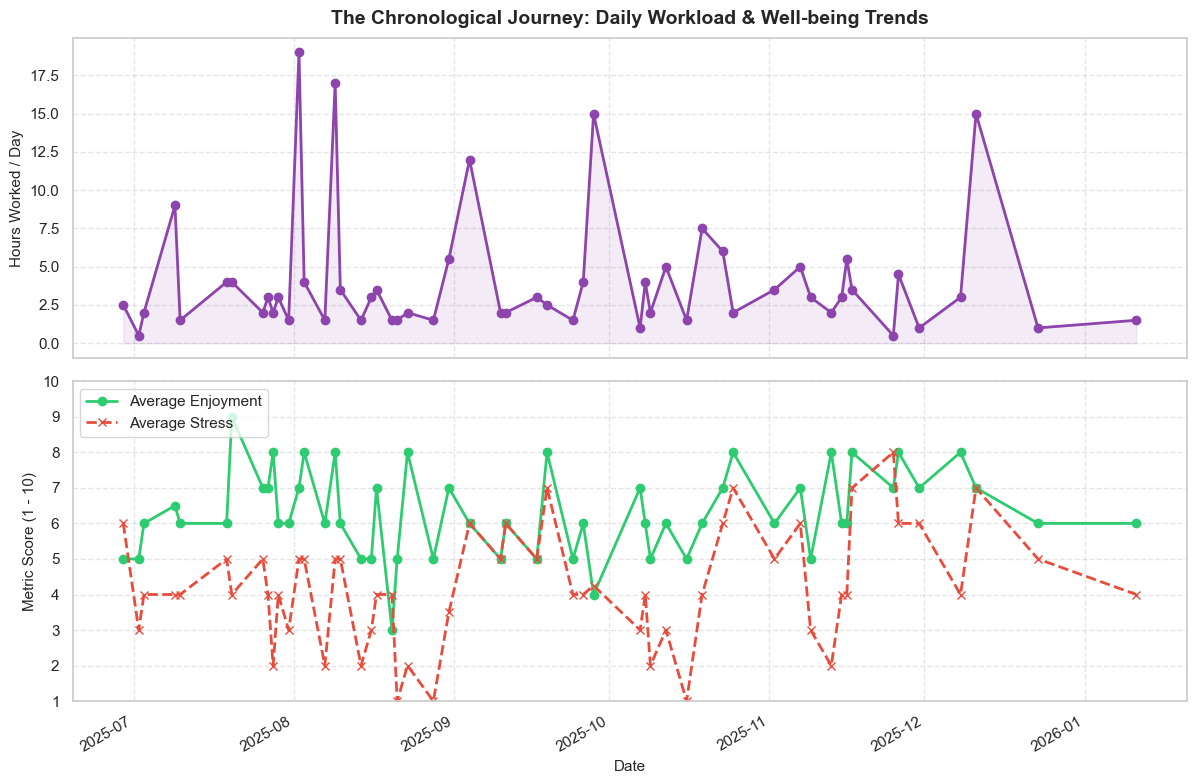

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

daily = df.groupby('date').agg({
    'duration': 'sum',
    'personal_enjoyment': 'mean',
    'stress_level': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(daily['date'], daily['duration'], color='#8e44ad', marker='o', linewidth=2, label='Total Hours')
ax1.fill_between(daily['date'], daily['duration'], color='#8e44ad', alpha=0.1) # Shading for visual weight
ax1.set_title("The Chronological Journey: Daily Workload & Well-being Trends", fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel("Hours Worked / Day", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(daily['date'], daily['personal_enjoyment'], color='#2ecc71', marker='o', linewidth=2, label='Average Enjoyment')
ax2.plot(daily['date'], daily['stress_level'], color='#e74c3c', marker='x', linestyle='--', linewidth=2, label='Average Stress')
ax2.set_ylabel("Metric Score (1 - 10)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylim(1, 10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white')

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

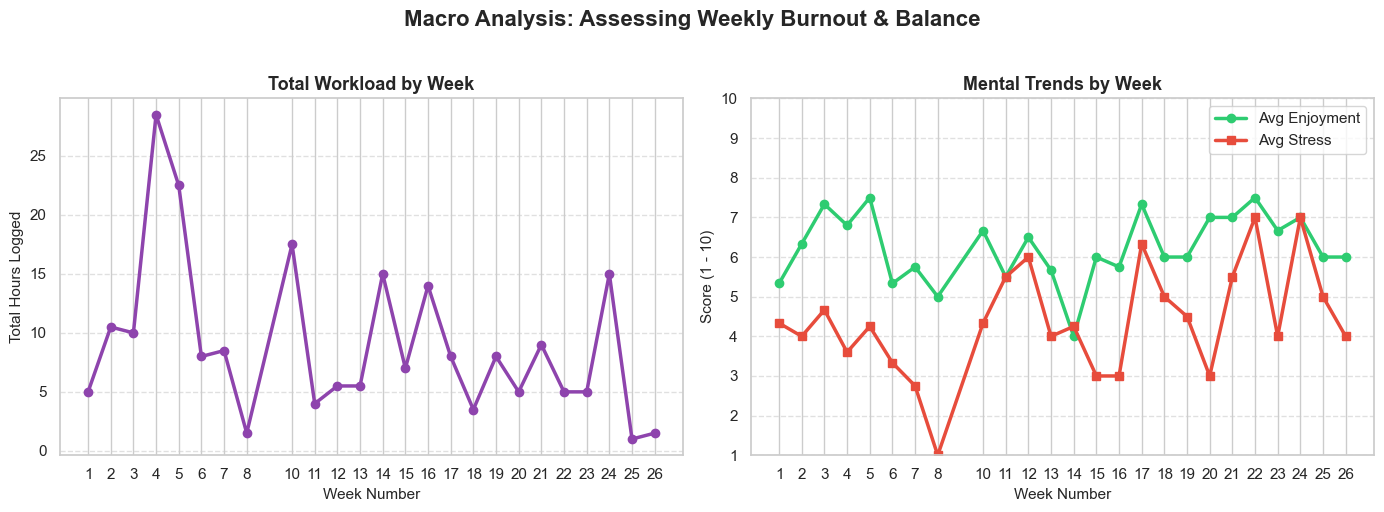

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Aggregate data by week
weekly_data = df.groupby('week').agg({
    'duration': 'sum',               # Total hours worked that week
    'personal_enjoyment': 'mean',    # Average enjoyment score
    'stress_level': 'mean'           # Average stress score
}).reset_index()

# 2. Initialize side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Weekly Workload (Total Hours)
ax1.plot(weekly_data['week'], weekly_data['duration'], color='#8e44ad', marker='o', linewidth=2.5)
ax1.set_title("Total Workload by Week", fontsize=13, fontweight='bold')
ax1.set_xlabel("Week Number", fontsize=11)
ax1.set_ylabel("Total Hours Logged", fontsize=11)
ax1.set_xticks(weekly_data['week']) # Ensure integer ticks for weeks
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot B: Weekly Emotional Well-being (Averages)
ax2.plot(weekly_data['week'], weekly_data['personal_enjoyment'], color='#2ecc71', marker='o', linewidth=2.5, label='Avg Enjoyment')
ax2.plot(weekly_data['week'], weekly_data['stress_level'], color='#e74c3c', marker='s', linewidth=2.5, label='Avg Stress')
ax2.set_title("Mental Trends by Week", fontsize=13, fontweight='bold')
ax2.set_xlabel("Week Number", fontsize=11)
ax2.set_ylabel("Score (1 - 10)", fontsize=11)
ax2.set_ylim(1, 10)
ax2.set_xticks(weekly_data['week'])
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(loc='best', frameon=True, facecolor='white')

# Final layout polish
plt.suptitle("Macro Analysis: Assessing Weekly Burnout & Balance", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()